## Controlled NOT Gate

* Conditionally flips the target qubit if the control qubit is $\vert{}1\rangle$.
* Abbreviated as CNOT or CX (Controlled X).

q0 (Control)  ───●───
                 │
q1 (Target)   ───┼───

## Key Concepts

* Operation: A two-qubit quantum operation that performs a Pauli-X operation on the target qubit if and only if the control qubit is $\vert{}1\rangle$.
* Circuit Representation:
* The two qubits are connected by a vertical line.
   * Control qubit: Indicated by a small solid dot (on $q_0$ in the diagram).
   * Target qubit: Indicated by a larger circle enclosing a plus symbol (on $q_1$ in the diagram).

## Matrix Representation
In the standard computational basis $\{\vert{}00\rangle, \vert{}01\rangle, \vert{}10\rangle, \vert{}11\rangle\}$ where the first qubit is the control:
$$\text{CNOT} = \begin{pmatrix} 1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \\ 0 & 0 & 0 & 1 \\ 0 & 0 & 1 & 0 \end{pmatrix}$$

* Top-left quadrant: Resembles a $2 \times 2$ Identity matrix ($I$).
* Bottom-right quadrant: Resembles a $2 \times 2$ Pauli-X matrix ($X$).

## State Transitions (Truth Table)
The gate maps input states to output states as follows:

| Input State        | Control Bit | Target Action | Output State       |
|--------------------|-------------|---------------|--------------------|
| $\vert{}00\rangle$ | 0           | Unchanged     | $\vert{}00\rangle$ |
| $\vert{}01\rangle$ | 0           | Unchanged     | $\vert{}01\rangle$ |
| $\vert{}10\rangle$ | 1           | Flipped       | $\vert{}11\rangle$ |
| $\vert{}11\rangle$ | 1           | Flipped       | $\vert{}10\rangle$ |


### Example Calculation: CNOT acting on $|01\rangle$

When the control qubit is $|0\rangle$, the target qubit remains unchanged. Mathematically, this is represented by multiplying the CNOT matrix by the state vector for $|01\rangle$:

$$\text{CNOT}|01\rangle = \begin{bmatrix} 1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \\ 0 & 0 & 0 & 1 \\ 0 & 0 & 1 & 0 \end{bmatrix} \begin{bmatrix} 0 \\ 1 \\ 0 \\ 0 \end{bmatrix} = \begin{bmatrix} 0 \\ 1 \\ 0 \\ 0 \end{bmatrix} = |01\rangle$$

*   **Input Vector:** $\begin{bmatrix} 0 & 1 & 0 & 0 \end{bmatrix}^T$ corresponds to the state $|01\rangle$ in the standard computational basis ($\vert00\rangle, \vert01\rangle, \vert10\rangle, \vert11\rangle$).
*   **Result:** Because the control qubit (the first digit, $0$) is not active, the operation outputs the identical state vector.



### Example Calculation: CNOT acting on $|10\rangle$

When the control qubit is $|1\rangle$, the target qubit is flipped. Mathematically, multiplying the CNOT matrix by the state vector for $|10\rangle$ shifts the probability amplitude to $|11\rangle$:

$$\text{CNOT}|10\rangle = \begin{bmatrix} 1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \\ 0 & 0 & 0 & 1 \\ 0 & 0 & 1 & 0 \end{bmatrix} \begin{bmatrix} 0 \\ 0 \\ 1 \\ 0 \end{bmatrix} = \begin{bmatrix} 0 \\ 0 \\ 0 \\ 1 \end{bmatrix} = |11\rangle$$

*   **Input Vector:** $\begin{bmatrix} 0 & 0 & 1 & 0 \end{bmatrix}^T$ corresponds to the state $|10\rangle$ in the computational basis.
*   **Result:** Because the control qubit (the first digit, $1$) is active, the target qubit flips from $0$ to $1$, yielding the final output state vector for $|11\rangle$.



In [19]:
from qiskit import *
from qiskit import transpile
from qiskit.visualization import plot_histogram, array_to_latex, plot_bloch_multivector
from qiskit_aer import Aer
from qiskit.quantum_info.states import statevector
from qiskit.transpiler import AnalysisPass
from math import pi
import matplotlib.pyplot as plt

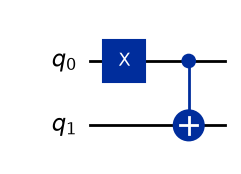

In [20]:
circuit = QuantumCircuit(2)
circuit.x(0) #Both bloch spheres will point down to the one state
circuit.cx(0, 1) #(Control, Target)
circuit.draw(output='mpl')

In [21]:
simulator = Aer.get_backend('statevector_simulator')
compiled = transpile(circuit, simulator)
result = simulator.run(compiled).result()
statevector = result.get_statevector()
array_to_latex(statevector)

<IPython.core.display.Latex object>

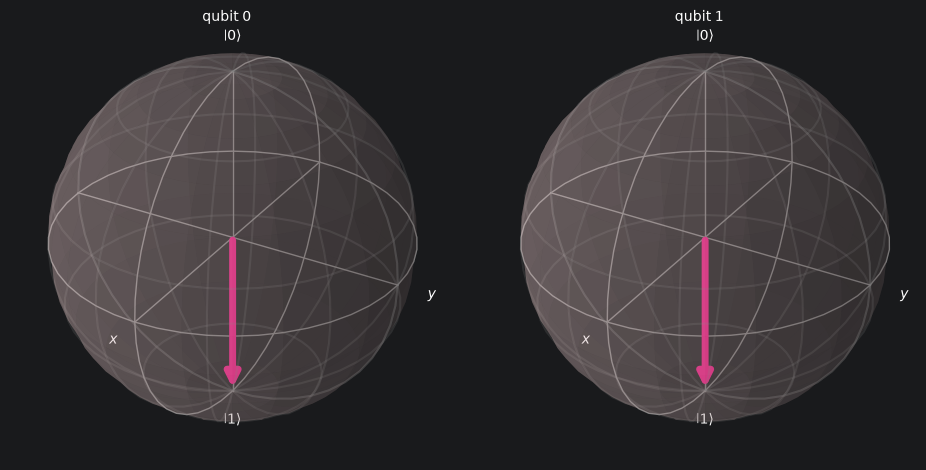

In [22]:
plot_bloch_multivector(statevector)

The C-NOT gate will only flip the target qubit if the control qubit is one at the time the C-NOT is executed.